In [ ]:
# pip install minisom


In [18]:
from minisom import MiniSom

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

import math
import numpy as np

import matplotlib.pyplot as plt

In [19]:
iris = load_iris()
features = iris.data
labels = iris.target
type(iris)
# print(f'{features[0]} ')


sklearn.utils._bunch.Bunch

In [20]:
sc = MinMaxScaler(feature_range = (0,1))
features = sc.fit_transform(features)

In [21]:
sigma = 1.5
lr = 0.5
n_features = features.shape[1]
n_samples = features.shape[0]
print(f"number of samples: {n_samples}")
print(math.sqrt(n_samples))

map_size = 5 * math.sqrt(n_samples)

map_height = map_width = math.ceil(math.sqrt(map_size))


print(f'(map_height, map_width) = ({map_height}, {map_width})')
print(f'Number of features: {n_features}')

number of samples: 150
12.24744871391589
(map_height, map_width) = (8, 8)
Number of features: 4


In [22]:
som = MiniSom(x=map_height, y=map_width, input_len=n_features, sigma=sigma, learning_rate=lr, 
              neighborhood_function='gaussian', random_seed=123)
 
som.pca_weights_init(features)
som.train(data=features, num_iteration=1000, verbose=True)  # random training

 [ 1000 / 1000 ] 100% - 0:00:00 left 
 quantization error: 0.06946712589245212


C:\Users\dhruv\AppData\Local\Programs\Python\Python313\Lib\site-packages\minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


In [23]:
# print('-------------\nDistance Map\n------------')
print(f'Shape: {som.distance_map().shape}')
# print(f'First Line: {som.distance_map().T}')

Shape: (8, 8)


In [24]:
frequencies = som.activation_response(features)
print(f'Frequencies:\n {np.array(frequencies, np.uint)}')
print(frequencies)

Frequencies:
 [[1 3 2 3 4 1 3 4]
 [2 5 3 3 3 4 2 3]
 [1 0 0 0 2 1 0 0]
 [4 1 3 4 1 0 2 4]
 [2 1 3 3 3 2 2 3]
 [3 3 0 3 4 1 1 3]
 [1 1 2 6 2 3 2 5]
 [4 0 3 2 4 4 3 2]]
[[1. 3. 2. 3. 4. 1. 3. 4.]
 [2. 5. 3. 3. 3. 4. 2. 3.]
 [1. 0. 0. 0. 2. 1. 0. 0.]
 [4. 1. 3. 4. 1. 0. 2. 4.]
 [2. 1. 3. 3. 3. 2. 2. 3.]
 [3. 3. 0. 3. 4. 1. 1. 3.]
 [1. 1. 2. 6. 2. 3. 2. 5.]
 [4. 0. 3. 2. 4. 4. 3. 2.]]


In [25]:
print(iris.target_names)

['setosa' 'versicolor' 'virginica']


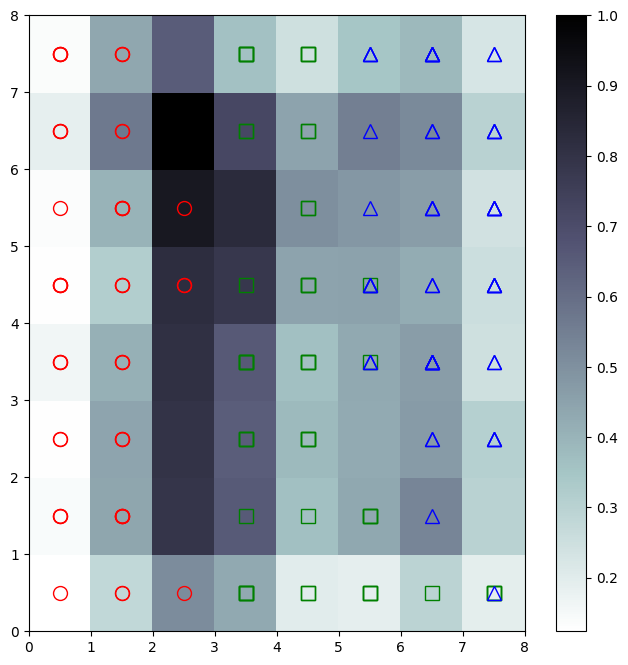

In [26]:
plt.figure(figsize=(map_height, map_width))

# plot U-matrix
u_matrix = som.distance_map().T
plt.pcolor(u_matrix, cmap='bone_r')
plt.colorbar()

# plot markers
markers = ['o', 's', '^']   # 'setosa', 'versicolor' 'virginica'
colors = ['r', 'g', 'b']
w0=[] 
w1=[]
lbl=[]
mkrs=[]

for feature, label in zip(features, labels):
    w = som.winner(feature)
    w0=np.concatenate((w0, w[0]), axis=None)
    w1=np.concatenate((w1, w[1]), axis=None)
    lbl=np.concatenate((lbl, label), axis=None)
    mkrs=np.concatenate((mkrs,iris.target_names[label]), axis=None)

    plt.plot(w[0] + 0.5, w[1] + 0.5, 
        markers[label], markeredgecolor = colors[label], 
        markerfacecolor = 'None', markersize = 10, markeredgewidth = 1)

plt.show()

In [27]:
winners = [som.winner(x) for x in features]

In [28]:
print(winners)

[(np.int64(0), np.int64(4)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(2)), (np.int64(0), np.int64(1)), (np.int64(0), np.int64(4)), (np.int64(1), np.int64(7)), (np.int64(0), np.int64(3)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(6)), (np.int64(0), np.int64(3)), (np.int64(1), np.int64(1)), (np.int64(0), np.int64(0)), (np.int64(0), np.int64(7)), (np.int64(0), np.int64(7)), (np.int64(1), np.int64(7)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(7)), (np.int64(0), np.int64(6)), (np.int64(1), np.int64(5)), (np.int64(0), np.int64(5)), (np.int64(0), np.int64(3)), (np.int64(2), np.int64(4)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(5)), (np.int64(0), np.int64(2)), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(5)), (np.int64(0), np.int64(7)), (np.int64(0), np.int64(7)), (np.int64(1), np.int64(2)), (np.int64(1), np.in

In [29]:
unique_coords = {coord: idx for idx, coord in enumerate(set(winners))}
int_labels = np.array([unique_coords[w] for w in winners])

In [30]:
print(int_labels)

[31 45  9 27 31 50 46 14 11 30 12 46 45 44 28 28 50 48 50 49 32 10 46 29
 14 45 48 32 32  9 45 13 28 28 30 30 32 31 11 48 31 47 27 29 49 45 49 27
 12 14 41 25 41 23  4 22 21 20  4  7 20 42 52  2  1 25 42 39 34 23  5 19
 34 19  4  4 41  6  2  3  0  0 39 26 42 21  6 34 22 23  7  2 40 20  7 22
 22 19 20 39 54 16 53 55 15 37 33  8 55 38 35 55 15 51 51 18 24 17 37 34
 38 51 37 55 18  8 55  5 36  8 37 17 36 26 26 37 54 43  5 53 54 15 16 38
 54 15 55 35 18  5]
